In [6]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError(
        "Start Jupyter from the repository root or the notebooks directory."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pickle

from bioGraph.data.loading import load_disease_genes, load_ppi_graph

In [7]:
data_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
results_dir = project_root / "outputs" / "results"
reports_dir = project_root / "outputs" / "reports"
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
ppi_path = data_dir / "PPI202207.txt"
disease_path = data_dir / "pcbi.1004120.s004.txt"

Ggen = load_ppi_graph(ppi_path)
diseases = load_disease_genes(disease_path)
nodelist = list(Ggen.nodes())


print(
    f"Loaded Ggen with {Ggen.number_of_nodes():,} nodes and "
    f"{Ggen.number_of_edges():,} undirected edges."
)
print(f"Average coordination number: {2 * Ggen.number_of_edges() / Ggen.number_of_nodes():.2f}")

print(f"Loaded diseases for {len(diseases)} diseases.")
print(f"Average number of genes per disease: {np.mean([len(genes) for genes in diseases.values()]):.2f}")
print(f"Example: breast neoplasms has {len(diseases['breast neoplasms'])} genes.")


Loaded Ggen with 17,504 nodes and 354,647 undirected edges.
Average coordination number: 40.52
Loaded diseases for 70 diseases.
Average number of genes per disease: 40.61
Example: breast neoplasms has 40 genes.


avg. distance: 2.6392774682021116
avg. coordination number: 40.52182358318099
std. coordination number: 51.14234561095579


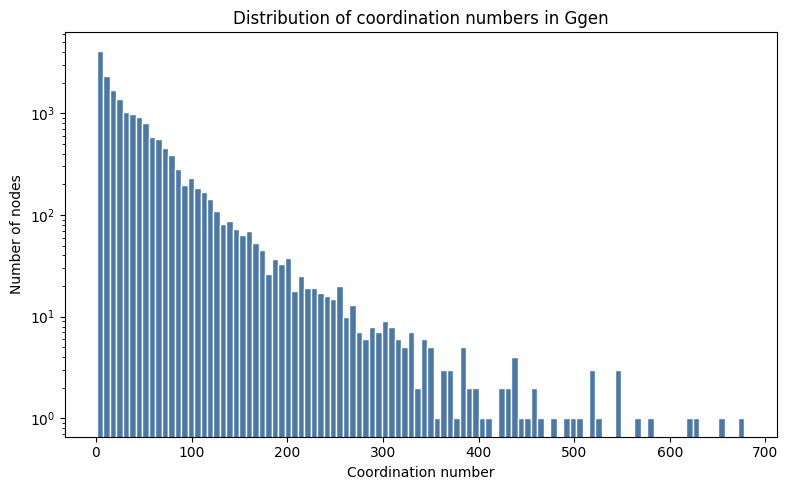

In [8]:
# Graph properties

coordination_numbers = np.array([degree for _, degree in Ggen.degree()])

print('avg. distance:', np.log(Ggen.number_of_nodes()) / np.log(2 * Ggen.number_of_edges() / Ggen.number_of_nodes()))
print('avg. coordination number:', coordination_numbers.mean())
print('std. coordination number:', coordination_numbers.std())


plt.figure(figsize=(8, 5))
plt.hist(coordination_numbers, bins=2*50, color='#4C78A8', edgecolor='white')
plt.xlabel('Coordination number')
plt.yscale('log')
plt.ylabel('Number of nodes')
plt.title('Distribution of coordination numbers in Ggen')
plt.tight_layout()
plt.show()

In [9]:
breast_gene = diseases['breast neoplasms'][0]
neighbors = sorted(Ggen.neighbors(breast_gene))
neighbor_symbols = [Ggen.nodes[gene_id].get('symbol', str(gene_id)) for gene_id in neighbors]

print(f'First breast neoplasms gene: {breast_gene} ({Ggen.nodes[breast_gene].get("symbol", "unknown")})')
print(f'Connected to {len(neighbors)} genes:')
#list(zip(neighbors, neighbor_symbols))

First breast neoplasms gene: 83990 (BRIP1)
Connected to 42 genes:


Compute properties of all diseaes (takes approx. 10 min)

In [10]:
recompute_diseases_prop = False

if recompute_diseases_prop:

    diseases_prop = {}

    for disease_name, disease_genes in diseases.items():
        disease_genes_in_graph = [gene for gene in disease_genes if gene in Ggen]
        disease_subgraph = Ggen.subgraph(disease_genes_in_graph).copy()
        cluster_sets = sorted(nx.connected_components(disease_subgraph), key=len, reverse=True)
        clusters = [sorted(cluster) for cluster in cluster_sets]
        cluster_sizes = [len(cluster) for cluster in clusters]
        cluster_distances = []

        for source_index, source_cluster in enumerate(cluster_sets):
            shortest_paths = nx.multi_source_dijkstra_path_length(Ggen, source_cluster)
            distances_to_other_clusters = []

            for target_index, target_cluster in enumerate(cluster_sets):
                if source_index == target_index:
                    distances_to_other_clusters.append(0)
                    continue

                min_distance = min(
                    (shortest_paths[gene] for gene in target_cluster if gene in shortest_paths),
                    default=float('inf')
                )
                distances_to_other_clusters.append(min_distance)

            cluster_distances.append(distances_to_other_clusters)

        diseases_prop[disease_name] = {
            'genes': disease_genes,
            'numb_genes': len(disease_genes),
            'clusters': clusters,
            'cluster_sizes': cluster_sizes,
            'cluster_distances': np.array(cluster_distances),
        }

    print(f'Built diseases_prop for {len(diseases_prop)} diseases.')
    print(diseases_prop['breast neoplasms'].keys())
    print(diseases_prop['breast neoplasms']['cluster_sizes'])

    pickle.dump(diseases_prop, (processed_dir / "diseases_prop.pkl").open("wb"))

else:
    diseases_prop = pickle.load((processed_dir / "diseases_prop.pkl").open("rb"))

## Investigate Clusters

In [11]:
disease_name = 'breast neoplasms'

print(f'Disease: {disease_name}')
print(f'Number of disease genes in the interactome: {diseases_prop[disease_name]["numb_genes"]}')
print(f'Number of clusters: {len(diseases_prop[disease_name]["clusters"])}')
print(f'Cluster sizes: {diseases_prop[disease_name]["cluster_sizes"]}')
print('Minimum distances between clusters:')
print(diseases_prop[disease_name]["cluster_distances"])

Disease: breast neoplasms
Number of disease genes in the interactome: 40
Number of clusters: 19
Cluster sizes: [21, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Minimum distances between clusters:
[[0 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
 [2 0 4 3 2 2 2 3 2 3 3 3 3 3 3 2 3 2 3]
 [2 4 0 4 3 3 3 4 3 4 3 4 4 3 3 3 3 3 3]
 [3 3 4 0 3 4 3 4 3 4 4 4 4 4 4 4 3 3 4]
 [2 2 3 3 0 3 3 3 2 3 3 3 2 3 3 3 3 3 3]
 [2 2 3 4 3 0 3 3 3 3 3 2 2 3 3 3 3 2 3]
 [2 2 3 3 3 3 0 3 3 3 3 3 3 3 3 3 3 2 3]
 [2 3 4 4 3 3 3 0 2 4 4 3 3 3 3 3 3 3 3]
 [2 2 3 3 2 3 3 2 0 3 3 2 2 3 3 3 3 3 3]
 [2 3 4 4 3 3 3 4 3 0 4 3 3 3 3 3 3 3 3]
 [2 3 3 4 3 3 3 4 3 4 0 3 3 3 3 3 4 4 4]
 [2 3 4 4 3 2 3 3 2 3 3 0 3 3 3 3 3 3 3]
 [2 3 4 4 2 2 3 3 2 3 3 3 0 3 3 3 3 3 3]
 [2 3 3 4 3 3 3 3 3 3 3 3 3 0 2 3 3 2 3]
 [2 3 3 4 3 3 3 3 3 3 3 3 3 2 0 3 3 3 3]
 [2 2 3 4 3 3 3 3 3 3 3 3 3 3 3 0 3 3 4]
 [2 3 3 3 3 3 3 3 3 3 4 3 3 3 3 3 0 3 4]
 [2 2 3 3 3 2 2 3 3 3 4 3 3 2 3 3 3 0 3]
 [2 3 3 4 3 3 3 3 3 3 4 3 3 3 3 4 4 3 0]]


In [12]:
avg_cluster_size = np.mean([len(d['clusters']) for d in diseases_prop.values()])
std_cluster_size = np.std([len(d['clusters']) for d in diseases_prop.values()])
print(f'Average number of clusters per disease: {avg_cluster_size:.2f} +/- {std_cluster_size:.2f}')



Average number of clusters per disease: 24.94 +/- 20.06


In [13]:
for disease_name, disease_info in diseases_prop.items():
    print(f'Disease: {disease_name}')
    print(f'Number of disease genes in the interactome: {disease_info["numb_genes"]}')
    print(f'Number of clusters: {len(disease_info["clusters"])}')
    print()

Disease: adrenal gland diseases
Number of disease genes in the interactome: 18
Number of clusters: 16

Disease: alzheimer disease
Number of disease genes in the interactome: 29
Number of clusters: 22

Disease: amino acid metabolism inborn errors
Number of disease genes in the interactome: 52
Number of clusters: 30

Disease: amyotrophic lateral sclerosis
Number of disease genes in the interactome: 21
Number of clusters: 17

Disease: anemia aplastic
Number of disease genes in the interactome: 21
Number of clusters: 5

Disease: anemia hemolytic
Number of disease genes in the interactome: 29
Number of clusters: 17

Disease: aneurysm
Number of disease genes in the interactome: 15
Number of clusters: 12

Disease: arrhythmias cardiac
Number of disease genes in the interactome: 30
Number of clusters: 26

Disease: arterial occlusive diseases
Number of disease genes in the interactome: 44
Number of clusters: 38

Disease: arteriosclerosis
Number of disease genes in the interactome: 38
Number of c

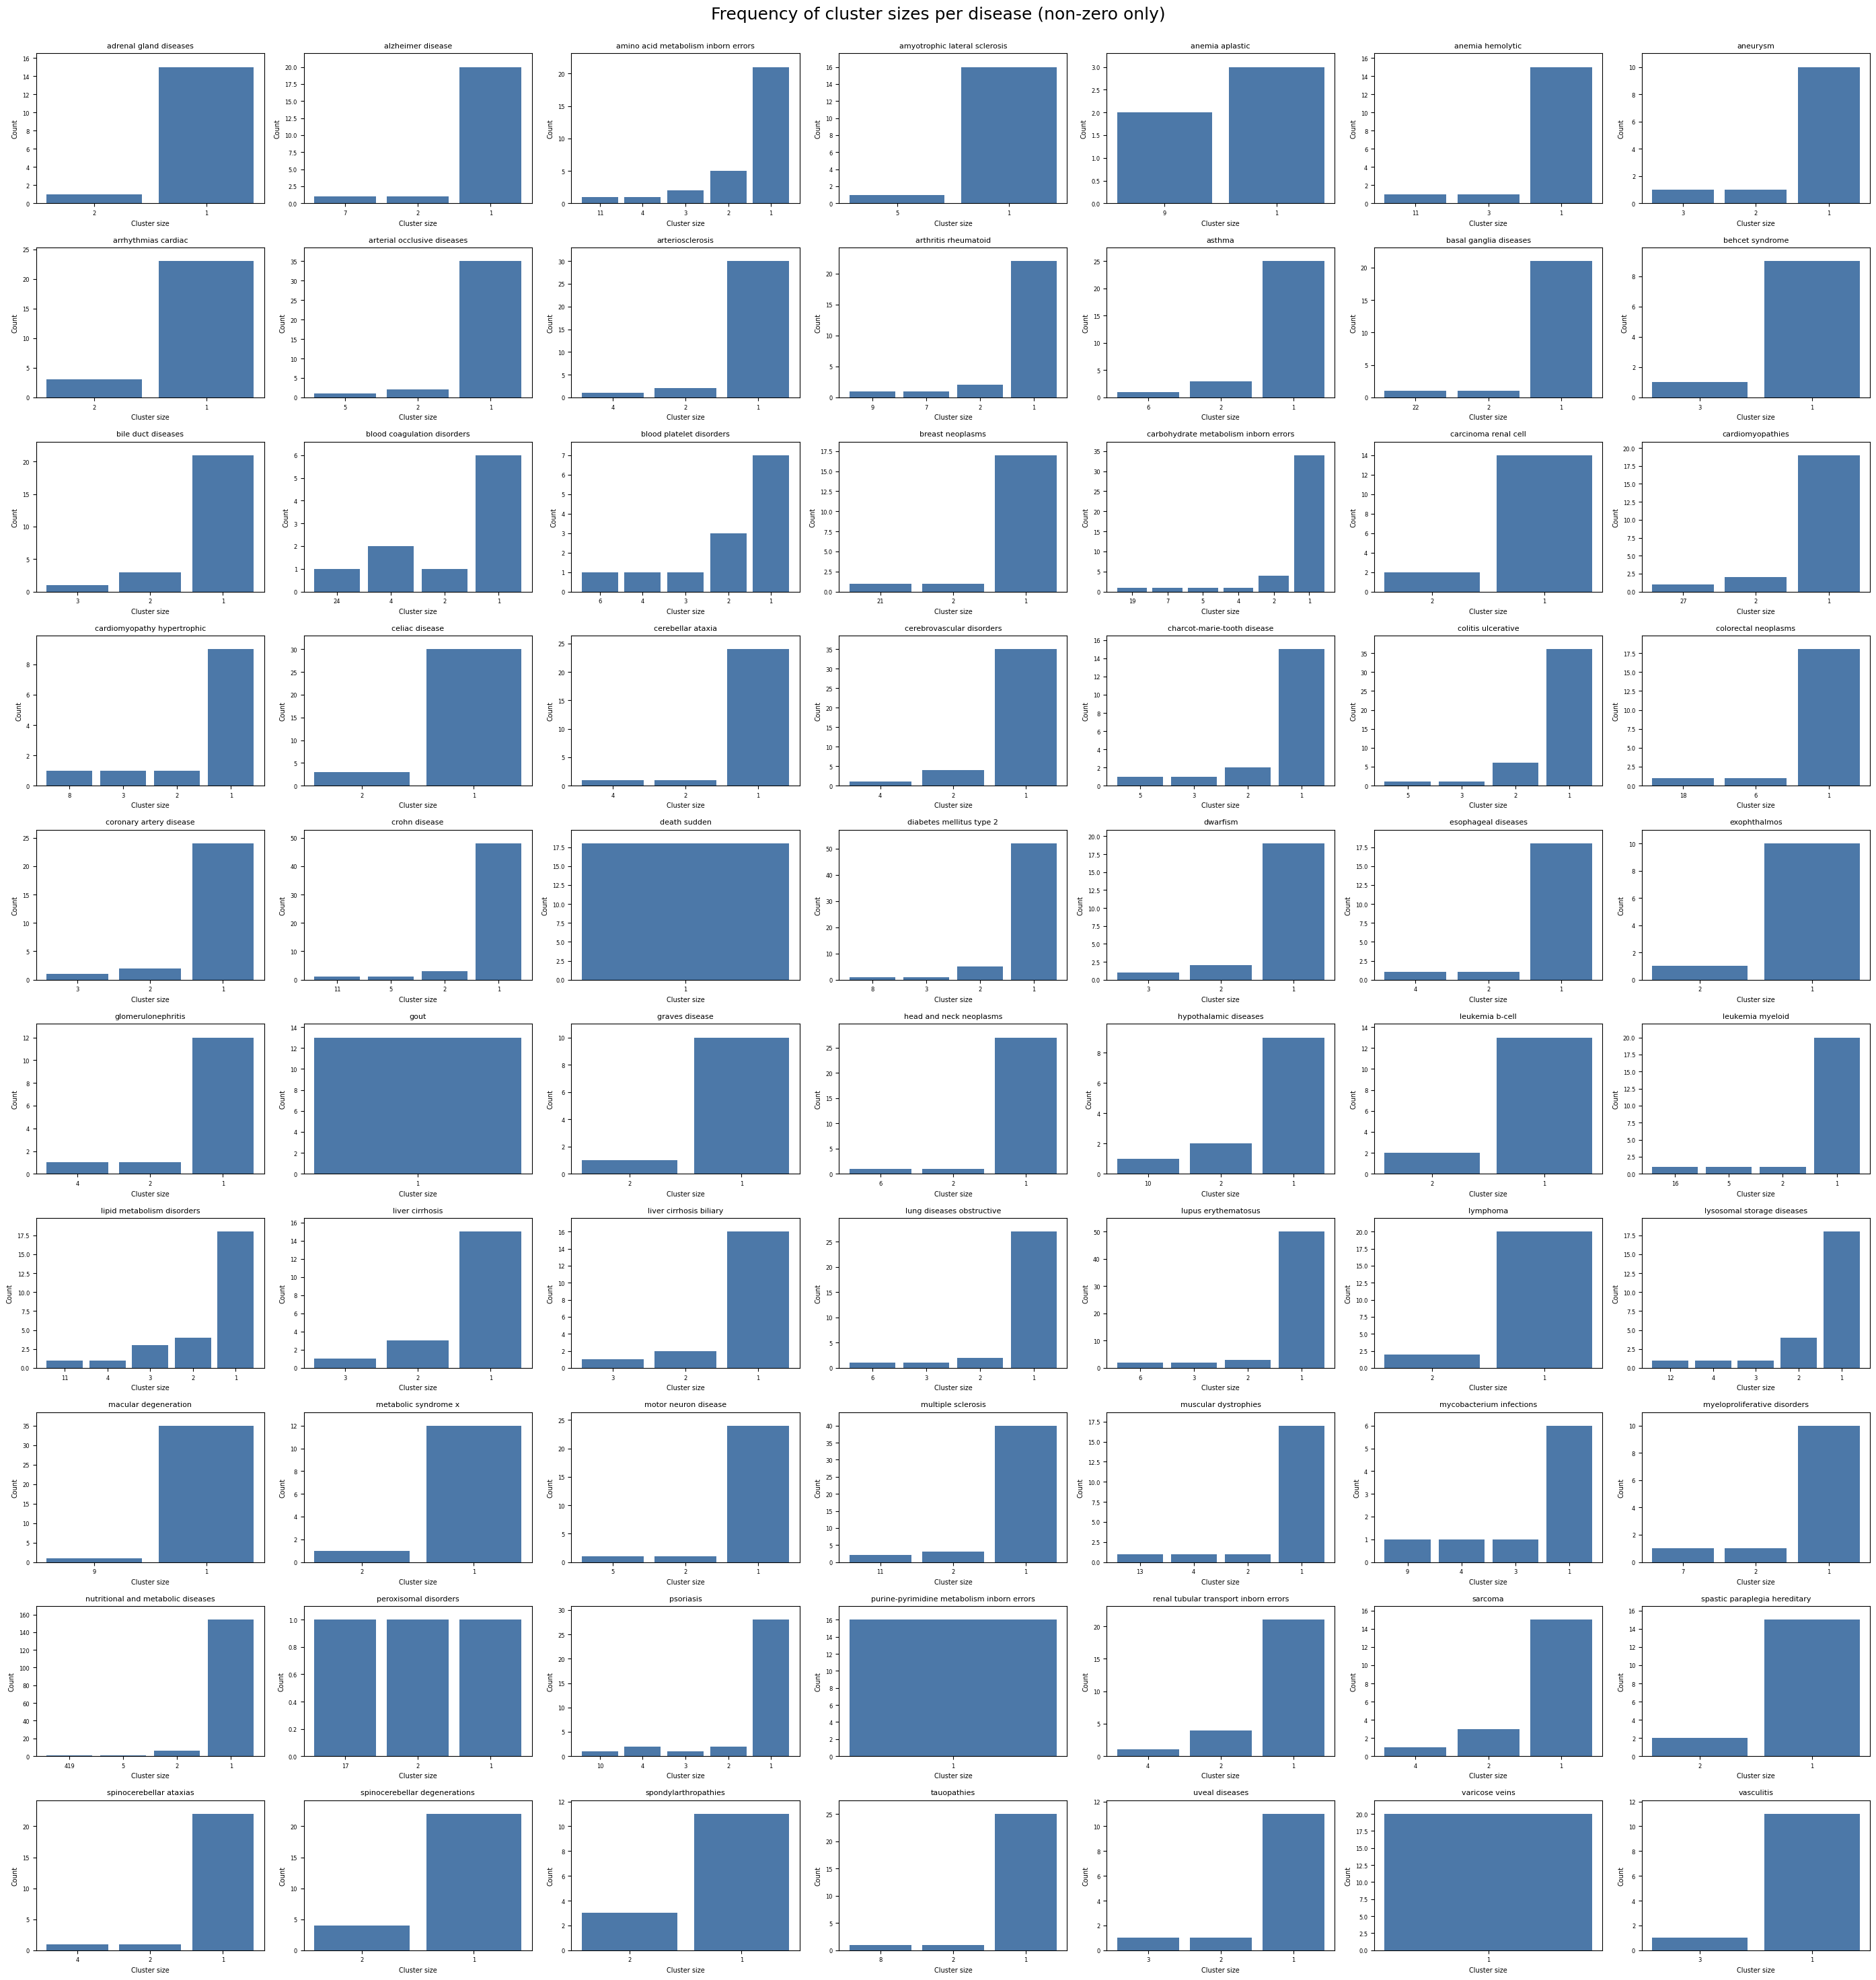

In [14]:
disease_names = sorted(diseases_prop.keys())
num_diseases = len(disease_names)

ncols = 7
nrows = int(np.ceil(num_diseases / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(28, 3 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for ax, disease_name in zip(axes, disease_names):
    cluster_sizes = np.array(diseases_prop[disease_name]['cluster_sizes'])
    non_zero_sizes = cluster_sizes[cluster_sizes > 0]

    if non_zero_sizes.size == 0:
        ax.axis('off')
        continue

    unique_sizes, counts = np.unique(non_zero_sizes, return_counts=True)
    sort_idx = np.argsort(unique_sizes)[::-1]
    unique_sizes = unique_sizes[sort_idx]
    counts = counts[sort_idx]

    x = np.arange(len(unique_sizes))
    ax.bar(x, counts, color='#4C78A8', width=0.85)

    ax.set_title(disease_name, fontsize=8)
    ax.set_xlabel('Cluster size', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(axis='both', labelsize=6)

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in unique_sizes])

    y_max = int(counts.max())
    ax.set_ylim(0, y_max * 1.1 if y_max > 0 else 1)

for ax in axes[num_diseases:]:
    ax.axis('off')

fig.suptitle('Frequency of cluster sizes per disease (non-zero only)', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
def plot_disease_cluster_map(disease_name, show=True):
    disease_info = diseases_prop[disease_name]
    cluster_sizes = np.array(disease_info['cluster_sizes'])
    distance_matrix = np.array(disease_info['cluster_distances'])
    n_clusters = len(cluster_sizes)

    cluster_graph = nx.Graph()
    for cluster_index, size in enumerate(cluster_sizes):
        cluster_graph.add_node(cluster_index, size=int(size))

    for i in range(n_clusters):
        positive_distances = [
            distance_matrix[i, j]
            for j in range(n_clusters)
            if i != j and np.isfinite(distance_matrix[i, j]) and distance_matrix[i, j] > 0
        ]
        if not positive_distances:
            continue

        closest_distance = min(positive_distances)
        if closest_distance >= 4:
            continue

        for j in range(i + 1, n_clusters):
            distance = distance_matrix[i, j]
            if np.isfinite(distance) and distance == closest_distance:
                cluster_graph.add_edge(i, j, distance=int(distance), weight=1.0 / float(distance))

    largest_cluster_index = int(np.argmax(cluster_sizes))

    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        raw_positions = graphviz_layout(cluster_graph, prog='neato')
    except Exception:
        try:
            from networkx.drawing.nx_pydot import graphviz_layout
            raw_positions = graphviz_layout(cluster_graph, prog='neato')
        except Exception:
            # Dependency-free fallback compatible with older NetworkX releases.
            raw_positions = nx.kamada_kawai_layout(
                cluster_graph,
                weight='weight',
            )

    raw_positions = {node: np.array(pos, dtype=float) for node, pos in raw_positions.items()}
    node_sizes = 700 + 900 * np.sqrt(cluster_sizes)
    node_radii = {node: np.sqrt(size) / 210.0 for node, size in zip(cluster_graph.nodes(), node_sizes)}
    padding = 0.24

    positions = {}
    components = list(nx.connected_components(cluster_graph))
    main_component = next(component for component in components if largest_cluster_index in component)
    main_graph = cluster_graph.subgraph(main_component)
    main_distances = nx.single_source_shortest_path_length(main_graph, largest_cluster_index)

    positions[largest_cluster_index] = np.array([0.0, 0.0])
    previous_shell_radius = node_radii[largest_cluster_index]

    for shell_level in sorted(set(main_distances.values())):
        if shell_level == 0:
            continue

        shell_nodes = [node for node, level in main_distances.items() if level == shell_level]
        shell_nodes.sort(key=lambda node: np.arctan2(raw_positions[node][1], raw_positions[node][0]))
        shell_node_radii = [node_radii[node] for node in shell_nodes]
        required_radius = sum(2 * radius + padding for radius in shell_node_radii) / (2 * np.pi)
        shell_radius = max(
            previous_shell_radius + max(shell_node_radii) + padding,
            required_radius,
            shell_level * 1.9,
        )
        angles = np.linspace(0, 2 * np.pi, len(shell_nodes), endpoint=False)

        for node, angle in zip(shell_nodes, angles):
            positions[node] = shell_radius * np.array([np.cos(angle), np.sin(angle)])

        previous_shell_radius = shell_radius + max(shell_node_radii)

    side_offset = -(previous_shell_radius + 2.5)
    for component in components:
        if component == main_component:
            continue

        component_nodes = sorted(component, key=lambda node: np.arctan2(raw_positions[node][1], raw_positions[node][0]))
        component_radii = [node_radii[node] for node in component_nodes]
        component_radius = max(
            sum(2 * radius + padding for radius in component_radii) / (2 * np.pi),
            1.0,
        )
        angles = np.linspace(0, 2 * np.pi, len(component_nodes), endpoint=False)
        component_center = np.array([side_offset - component_radius, 0.0])

        for node, angle in zip(component_nodes, angles):
            positions[node] = component_center + component_radius * np.array([np.cos(angle), np.sin(angle)])

        side_offset -= 2 * component_radius + 2.0

    for _ in range(400):
        moved = False
        for i in cluster_graph.nodes():
            for j in cluster_graph.nodes():
                if j <= i:
                    continue

                delta = positions[j] - positions[i]
                distance = np.linalg.norm(delta)
                min_distance = node_radii[i] + node_radii[j] + padding

                if distance >= min_distance:
                    continue

                moved = True
                if distance == 0:
                    direction = np.array([1.0, 0.0])
                else:
                    direction = delta / distance

                shift = 0.55 * (min_distance - max(distance, 1e-9)) * direction
                if i != largest_cluster_index:
                    positions[i] = positions[i] - shift
                if j != largest_cluster_index:
                    positions[j] = positions[j] + shift

        if not moved:
            break

    if largest_cluster_index in positions:
        center = positions[largest_cluster_index]
        positions = {node: pos - center for node, pos in positions.items()}

    fig, ax = plt.subplots(figsize=(13, 11))
    nx.draw_networkx_nodes(
        cluster_graph,
        positions,
        node_size=node_sizes,
        node_color='#7AA6DC',
        edgecolors='#1F4E79',
        linewidths=1.6,
        ax=ax,
    )

    nx.draw_networkx_edges(
        cluster_graph,
        positions,
        width=1.3,
        alpha=0.75,
        edge_color='#6B7280',
        ax=ax,
    )

    labels = {idx: str(int(size)) for idx, size in enumerate(cluster_sizes)}
    nx.draw_networkx_labels(
        cluster_graph,
        positions,
        labels=labels,
        font_size=10,
        font_weight='bold',
        ax=ax,
    )

    edge_labels = {(u, v): data['distance'] for u, v, data in cluster_graph.edges(data=True)}
    nx.draw_networkx_edge_labels(
        cluster_graph,
        positions,
        edge_labels=edge_labels,
        font_size=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
        ax=ax,
    )

    ax.set_title(f'{disease_name}: cluster map (automatic layout, closest connections only)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()

    if show:
        plt.show()

    return fig


plot_disease_cluster_map('adrenal gland diseases');

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = figures_dir / 'disease_cluster_maps.pdf'

with PdfPages(pdf_path) as pdf:
    for disease_name in sorted(diseases_prop):
        fig = plot_disease_cluster_map(disease_name, show=False)
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f'Saved {len(diseases_prop)} disease cluster maps to {pdf_path}')

## Investigate Connectivity

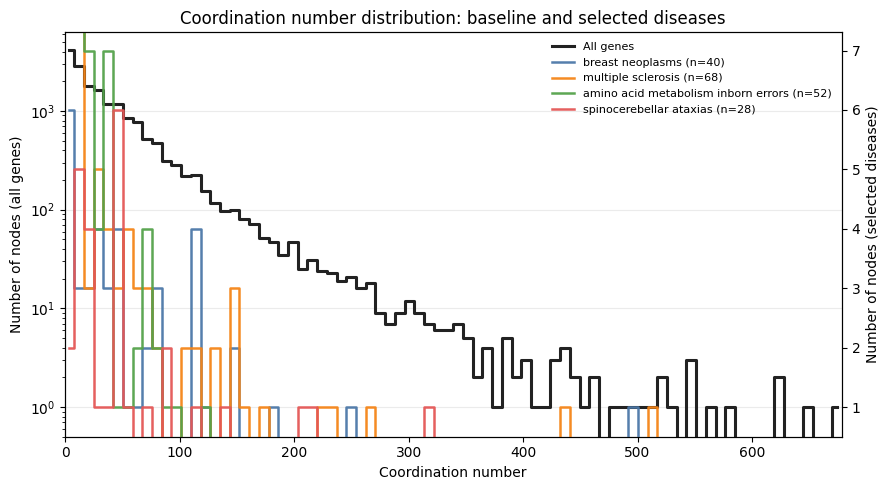

In [15]:
selected_diseases = [
    'breast neoplasms',
    'multiple sclerosis',
    'amino acid metabolism inborn errors',
    'spinocerebellar ataxias'
]

coordination_numbers = np.array([degree for _, degree in Ggen.degree()])
max_degree = int(coordination_numbers.max())
n_bins = min(80, max(20, max_degree // 8))
bin_edges = np.linspace(-0.5, max_degree + 0.5, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, ax_left = plt.subplots(figsize=(9, 5))
ax_right = ax_left.twinx()

baseline_counts, _ = np.histogram(coordination_numbers, bins=bin_edges)
ax_left.step(bin_centers, baseline_counts, where='mid', color='#222222', linewidth=2.2, label='All genes')

palette = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']
for disease_name, color in zip(selected_diseases, palette):
    disease_genes = [gene for gene in diseases.get(disease_name, []) if gene in Ggen]
    if not disease_genes:
        continue

    disease_coordination_numbers = np.array([Ggen.degree(gene) for gene in disease_genes])
    disease_counts, _ = np.histogram(disease_coordination_numbers, bins=bin_edges)
    ax_right.step(
        bin_centers,
        disease_counts,
        where='mid',
        color=color,
        linewidth=1.8,
        alpha=0.95,
        label=f"{disease_name} (n={len(disease_genes)})",
    )

ax_left.set_xlabel('Coordination number')
ax_left.set_ylabel('Number of nodes (all genes)')
ax_right.set_ylabel('Number of nodes (selected diseases)')
ax_left.set_yscale('log')
ax_right.set_yscale('linear')
ax_left.set_xlim(-0.5, max_degree + 0.5)
ax_left.set_ylim(bottom=0.5)
ax_left.set_title('Coordination number distribution: baseline and selected diseases')
ax_left.grid(True, axis='y', which='major', alpha=0.25)
left_bottom, left_top = ax_left.get_ylim()
left_one_position = np.log(1 / left_bottom) / np.log(left_top / left_bottom)
right_bottom = 0.5
right_top = right_bottom + (1 - right_bottom) / left_one_position
ax_right.set_ylim(right_bottom, right_top)
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

### Rank genes on relevance frequency

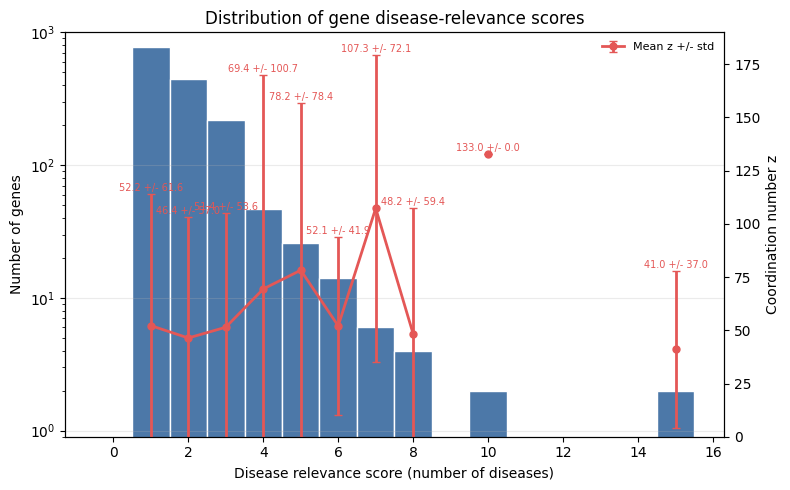

Scored 1,536 unique genes.
score 1: z = 52.22 +/- 61.60 (n=758)
score 2: z = 46.39 +/- 56.98 (n=446)
score 3: z = 51.44 +/- 53.56 (n=217)
score 4: z = 69.43 +/- 100.72 (n=47)
score 5: z = 78.23 +/- 78.40 (n=26)
score 6: z = 52.07 +/- 41.88 (n=14)
score 7: z = 107.33 +/- 72.14 (n=6)
score 8: z = 48.25 +/- 59.41 (n=4)
score 10: z = 133.00 +/- 0.00 (n=1)
score 15: z = 41.00 +/- 37.00 (n=2)


In [19]:
# Score each gene by the number of diseases it appears in
gene_scores = {}
for disease_genes in diseases.values():
    for gene in set(disease_genes):  # avoid double-counting if a disease list contains duplicates
        gene_scores[gene] = gene_scores.get(gene, 0) + 1

# (Optional) store score on graph nodes when gene exists in Ggen
nx.set_node_attributes(
    Ggen,
    {gene: score for gene, score in gene_scores.items() if gene in Ggen},
    name="disease_score"
)

score_values = np.array(list(gene_scores.values()), dtype=int)

# Histogram of score distribution
bins = np.arange(-0.5, score_values.max() + 1.5, 1)
gene_z = np.array([Ggen.degree(gene) for gene in gene_scores if gene in Ggen], dtype=float)
gene_scores_in_graph = np.array([gene_scores[gene] for gene in gene_scores if gene in Ggen], dtype=int)

score_levels = np.arange(0, score_values.max() + 1)
mean_z_by_score = []
std_z_by_score = []
n_genes_by_score = []

for score_level in score_levels:
    mask = gene_scores_in_graph == score_level
    z_values = gene_z[mask]
    n_genes_by_score.append(int(mask.sum()))
    if z_values.size == 0:
        mean_z_by_score.append(np.nan)
        std_z_by_score.append(np.nan)
    else:
        mean_z_by_score.append(float(np.mean(z_values)))
        std_z_by_score.append(float(np.std(z_values)))

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.hist(score_values, bins=bins, color="#4C78A8", edgecolor="white")
ax_left.set_yscale("log")
ax_left.set_ylim(0.9, 10**3)
ax_left.set_xlabel("Disease relevance score (number of diseases)")
ax_left.set_ylabel("Number of genes")
ax_left.set_title("Distribution of gene disease-relevance scores")
ax_left.grid(True, axis='y', which='major', alpha=0.25)

ax_right.errorbar(
    score_levels,
    mean_z_by_score,
    yerr=std_z_by_score,
    fmt='o-',
    color='#E45756',
    linewidth=2.0,
    markersize=5,
    capsize=3,
    label='Mean z +/- std',
)
ax_right.set_ylabel('Coordination number z')
ax_right.set_ylim(bottom=0)

for score_level, mean_z, std_z, n_genes in zip(score_levels, mean_z_by_score, std_z_by_score, n_genes_by_score):
    if np.isnan(mean_z):
        continue
    ax_right.text(
        score_level,
        mean_z + std_z + 0.5,
        f'{mean_z:.1f} +/- {std_z:.1f}',
        ha='center',
        va='bottom',
        fontsize=7,
        color='#E45756',
    )

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, frameon=False, fontsize=8, loc='upper right')
fig.tight_layout()
plt.show()

print(f"Scored {len(gene_scores):,} unique genes.")
for score_level, mean_z, std_z, n_genes in zip(score_levels, mean_z_by_score, std_z_by_score, n_genes_by_score):
    if np.isnan(mean_z):
        continue
    print(f"score {score_level}: z = {mean_z:.2f} +/- {std_z:.2f} (n={n_genes})")



### Rank PPI edges by disease relevance

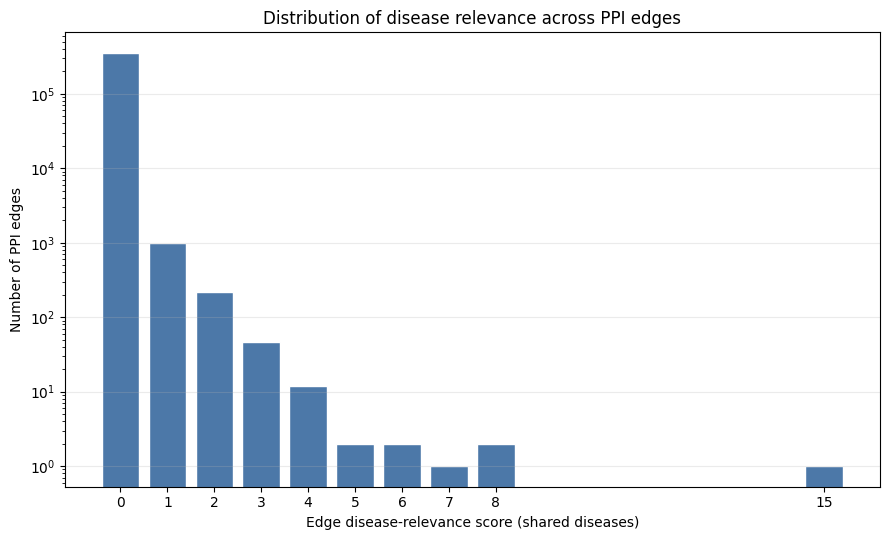

1,278 of 354,647 PPI edges connect two genes assigned to at least one common disease.

Top 20 disease-relevant edges:
 1. HLA-DQA2 (3118) -- HLA-DQB1 (3119): score=15 | arthritis rheumatoid, asthma, bile duct diseases, exophthalmos, glomerulonephritis, graves disease, liver cirrhosis, liver cirrhosis biliary, lung diseases obstructive, lupus erythematosus, lymphoma, multiple sclerosis, mycobacterium infections, nutritional and metabolic diseases, psoriasis
 2. HLA-DQA1 (3117) -- HLA-DQB1 (3119): score=8 | arthritis rheumatoid, asthma, glomerulonephritis, lung diseases obstructive, lupus erythematosus, multiple sclerosis, mycobacterium infections, nutritional and metabolic diseases
 3. HLA-DQA2 (3118) -- HLA-DQA1 (3117): score=8 | arthritis rheumatoid, asthma, glomerulonephritis, lung diseases obstructive, lupus erythematosus, multiple sclerosis, mycobacterium infections, nutritional and metabolic diseases
 4. HLA-DRA (3122) -- HLA-DQB1 (3119): score=7 | asthma, lung diseases obstructiv

In [17]:
# Map each gene to the diseases in which it is a known disease gene.
gene_disease_memberships = {}
for disease_name, disease_gene_ids in diseases.items():
    for gene_id in set(disease_gene_ids):
        gene_disease_memberships.setdefault(gene_id, set()).add(disease_name)

# An edge's disease-relevance score is the number of diseases shared by
# both endpoint genes. Score 0 means the interaction does not connect two
# known genes from the same disease.
edge_score_counts = np.zeros(len(diseases) + 1, dtype=np.int64)
ranked_disease_edges = []

for gene_a, gene_b in Ggen.edges():
    shared_diseases = (
        gene_disease_memberships.get(gene_a, set())
        & gene_disease_memberships.get(gene_b, set())
    )
    edge_score = len(shared_diseases)
    edge_score_counts[edge_score] += 1

    if edge_score > 0:
        ranked_disease_edges.append(
            {
                "gene_a": gene_a,
                "symbol_a": Ggen.nodes[gene_a].get("symbol", str(gene_a)),
                "gene_b": gene_b,
                "symbol_b": Ggen.nodes[gene_b].get("symbol", str(gene_b)),
                "disease_relevance_score": edge_score,
                "shared_diseases": sorted(shared_diseases),
            }
        )

ranked_disease_edges.sort(
    key=lambda edge: (
        -edge["disease_relevance_score"],
        edge["symbol_a"],
        edge["symbol_b"],
    )
)

observed_scores = np.flatnonzero(edge_score_counts)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(
    observed_scores,
    edge_score_counts[observed_scores],
    width=0.8,
    color="#4C78A8",
    edgecolor="white",
)
ax.set_yscale("log")
ax.set_xticks(observed_scores)
ax.set_xlabel("Edge disease-relevance score (shared diseases)")
ax.set_ylabel("Number of PPI edges")
ax.set_title("Distribution of disease relevance across PPI edges")
ax.grid(axis="y", which="major", alpha=0.25)
plt.tight_layout()
plt.show()

number_relevant = len(ranked_disease_edges)
print(
    f"{number_relevant:,} of {Ggen.number_of_edges():,} PPI edges "
    "connect two genes assigned to at least one common disease."
)
print("\nTop 20 disease-relevant edges:")
for rank, edge in enumerate(ranked_disease_edges[:20], start=1):
    disease_text = ", ".join(edge["shared_diseases"])
    print(
        f"{rank:>2}. {edge['symbol_a']} ({edge['gene_a']}) -- "
        f"{edge['symbol_b']} ({edge['gene_b']}): "
        f"score={edge['disease_relevance_score']} | {disease_text}"
    )
